In [4]:
!pip install chaid
!pip install graphviz

In [5]:
# Import libraries
import pandas as pd
import statsmodels.api as sm
from CHAID import Tree

In [7]:
# Import data
data = sm.datasets.get_rdataset("ResumeNames",
                                package = "AER").data
data.head()

,name,gender,ethnicity,quality,call,city,jobs,experience,honors,volunteer,...,minimum,equal,wanted,requirements,reqexp,reqcomm,reqeduc,reqcomp,reqorg,industry
0,Allison,female,cauc,low,no,chicago,2,6,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
1,Kristen,female,cauc,high,no,chicago,3,6,no,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
2,Lakisha,female,afam,low,no,chicago,1,6,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
3,Latonya,female,afam,high,no,chicago,4,6,no,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
4,Carrie,female,cauc,high,no,chicago,3,22,no,no,...,some,yes,secretary,yes,yes,no,no,yes,yes,health/education/social services


In [8]:
# Remove name variable
data = data.iloc[:,1:]
data.head()

,gender,ethnicity,quality,call,city,jobs,experience,honors,volunteer,military,...,minimum,equal,wanted,requirements,reqexp,reqcomm,reqeduc,reqcomp,reqorg,industry
0,female,cauc,low,no,chicago,2,6,no,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
1,female,cauc,high,no,chicago,3,6,no,yes,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
2,female,afam,low,no,chicago,1,6,no,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
3,female,afam,high,no,chicago,4,6,no,yes,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
4,female,cauc,high,no,chicago,3,22,no,no,no,...,some,yes,secretary,yes,yes,no,no,yes,yes,health/education/social services


In [9]:
# Find unique values
data.apply(pd.Series.nunique)

gender           2
ethnicity        2
quality          2
call             2
city             2
jobs             7
experience      26
honors           2
volunteer        2
military         2
holes            2
school           2
email            2
computer         2
special          2
college          2
minimum         13
equal            2
wanted           6
requirements     2
reqexp           2
reqcomm          2
reqeduc          2
reqcomp          2
reqorg           2
industry         7
dtype: int64

In [10]:
data.dtypes

gender          object
ethnicity       object
quality         object
call            object
city            object
jobs             int64
experience       int64
honors          object
volunteer       object
military        object
holes           object
school          object
email           object
computer        object
special         object
college         object
minimum         object
equal           object
wanted          object
requirements    object
reqexp          object
reqcomm         object
reqeduc         object
reqcomp         object
reqorg          object
industry        object
dtype: object

<Axes: xlabel='jobs', ylabel='Density'>

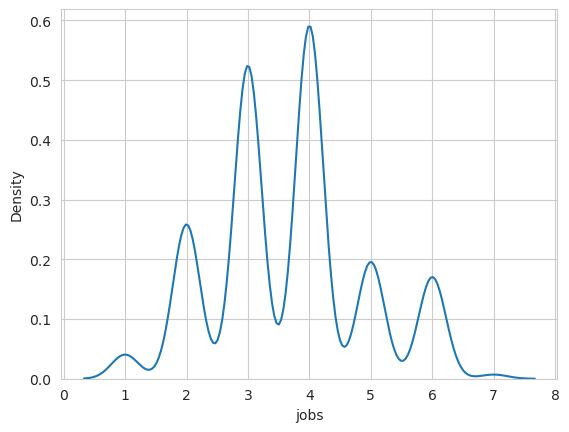

In [11]:
# Visualize jobs variable
import seaborn as sns
sns.set_style('whitegrid')
sns.kdeplot(data.jobs)

In [12]:
# Transform jobs variable
data.jobs = pd.cut(x = data.jobs,
                   bins = [-1, 2.9,4.9,9],
                   labels = [0,1,2])
data.jobs

0       0
1       1
2       0
3       1
4       1
       ..
4865    0
4866    1
4867    2
4868    1
4869    1
Name: jobs, Length: 4870, dtype: category
Categories (3, int64): [0 < 1 < 2]

In [13]:
data.jobs = pd.factorize(data.jobs)[0]
data.jobs

0       0
1       1
2       0
3       1
4       1
       ..
4865    0
4866    1
4867    2
4868    1
4869    1
Name: jobs, Length: 4870, dtype: int64

<Axes: xlabel='experience', ylabel='Density'>

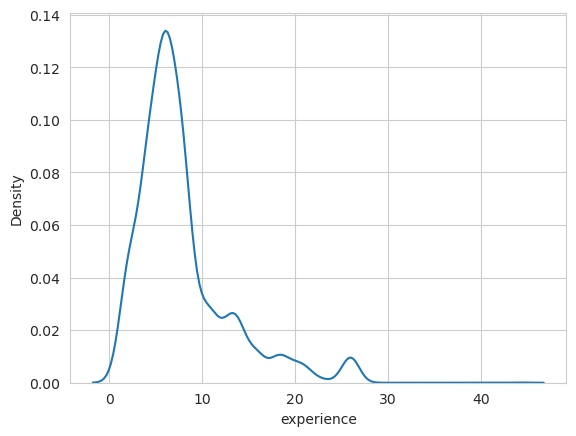

In [14]:
# Visualize experience variable
sns.set_style('whitegrid')
sns.kdeplot(data.experience)

In [15]:
# Transform experience variable
data.experience = pd.qcut(x = data.experience,
                   q = 3,
                   labels = [0,1,2])
data.experience = pd.factorize(data.experience)[0]
data.experience

0       0
1       0
2       0
3       0
4       1
       ..
4865    2
4866    0
4867    0
4868    2
4869    0
Name: experience, Length: 4870, dtype: int64

In [20]:
# Minimum variable
data.minimum.value_counts()

minimum
0    2758
2    1403
1     498
3     211
Name: count, dtype: int64

In [21]:
# Transform minimum variable
replacement_dictionary = {'none': 0,
                          '0': 0,
                          '0.5': 0,
                          '1': 1,
                          '2': 1,
                          'some': 2,
                          '3': 2,
                          '4': 2,
                          '5': 3,
                          '6': 3,
                          '7': 3,
                          '8': 3,
                          '10': 3}
data['minimum'] = data['minimum'].replace(replacement_dictionary)
data.minimum

0       3
1       3
2       3
3       3
4       2
       ..
4865    0
4866    0
4867    0
4868    0
4869    0
Name: minimum, Length: 4870, dtype: int64

In [22]:
# Transforming remaining variables
data = pd.get_dummies(data, drop_first = True)
data.head()

,jobs,experience,minimum,gender_male,ethnicity_cauc,quality_low,call_yes,city_chicago,honors_yes,volunteer_yes,...,reqcomm_yes,reqeduc_yes,reqcomp_yes,reqorg_yes,industry_finance/insurance/real estate,industry_health/education/social services,industry_manufacturing,industry_trade,industry_transport/communication,industry_unknown
0,0,0,3,False,True,True,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
1,1,0,3,False,True,False,False,True,False,True,...,False,False,True,False,False,False,True,False,False,False
2,0,0,3,False,False,True,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
3,1,0,3,False,False,False,False,True,False,True,...,False,False,True,False,False,False,True,False,False,False
4,1,1,2,False,True,False,False,True,False,False,...,False,False,True,True,False,True,False,False,False,False


# CHAID

In [23]:
# Get y name
y_name = data.call_yes.name
y_name

'call_yes'

In [24]:
# Get IV names
X_names = data.drop(columns = 'call_yes').columns
print(X_names)
print(len(X_names))

Index(['jobs', 'experience', 'minimum', 'gender_male', 'ethnicity_cauc',
       'quality_low', 'city_chicago', 'honors_yes', 'volunteer_yes',
       'military_yes', 'holes_yes', 'school_yes', 'email_yes', 'computer_yes',
       'special_yes', 'college_yes', 'equal_yes', 'wanted_office support',
       'wanted_other', 'wanted_retail sales', 'wanted_secretary',
       'wanted_supervisor', 'requirements_yes', 'reqexp_yes', 'reqcomm_yes',
       'reqeduc_yes', 'reqcomp_yes', 'reqorg_yes',
       'industry_finance/insurance/real estate',
       'industry_health/education/social services', 'industry_manufacturing',
       'industry_trade', 'industry_transport/communication',
       'industry_unknown'],
      dtype='object')
34


In [25]:
# CHAID tree
model = Tree.from_pandas_df(data,
                            dict(zip(X_names,
                                     ['ordinal']*3 + ['nominal'] * 31)),
                            y_name,
                            max_depth = 3,
                            min_child_node_size = 250)

In [26]:
from IPython.display import Image, display

rendered_output = model.render(path="a",
                               view=None)
display(Image(filename="a.png"))

TypeError: 'NoneType' object is not callable